In [1]:
# ========== 环境准备：导入库并设置画图中文 ==========
import warnings                          # 导入警告控制模块
warnings.filterwarnings('ignore')  # 忽略次要警告，输出更干净

import numpy as np           # 数值计算
import pandas as pd          # 表格数据处理
import matplotlib.pyplot as plt  # 绘图
import yfinance as yf        # 下载雅虎财经股票数据（需联网）

plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows 黑体；Mac 可改 PingFang SC
plt.rcParams['axes.unicode_minus'] = False     # 负号正常显示

print('环境就绪 ✓')                       # 提示：环境加载完成


环境就绪 ✓


In [2]:
# ========== 下载苹果 AAPL 最近约 1 年的日线数据 ==========
aapl = yf.download('AAPL', period='1y', progress=False, multi_level_index=False)  # 下载
aapl = aapl.dropna()  # 删掉有空值的行，保证数据完整

print('数据形状（行=交易日，列=字段）：', aapl.shape)  # 例如 (251, 5)
print('\n前 5 行：')  # 提示下方表格
display(aapl.head())  # Jupyter 里美观显示表格前几行

print('\n各列含义速查：')  # 打印列名说明
for col in aapl.columns:  # 遍历每一列的名字
    print(f'  {col}')  # 格式化打印


1 Failed download:
['AAPL']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


数据形状（行=交易日，列=字段）： (0, 6)

前 5 行：


,Adj Close,Close,High,Low,Open,Volume



各列含义速查：
  Adj Close
  Close
  High
  Low
  Open
  Volume


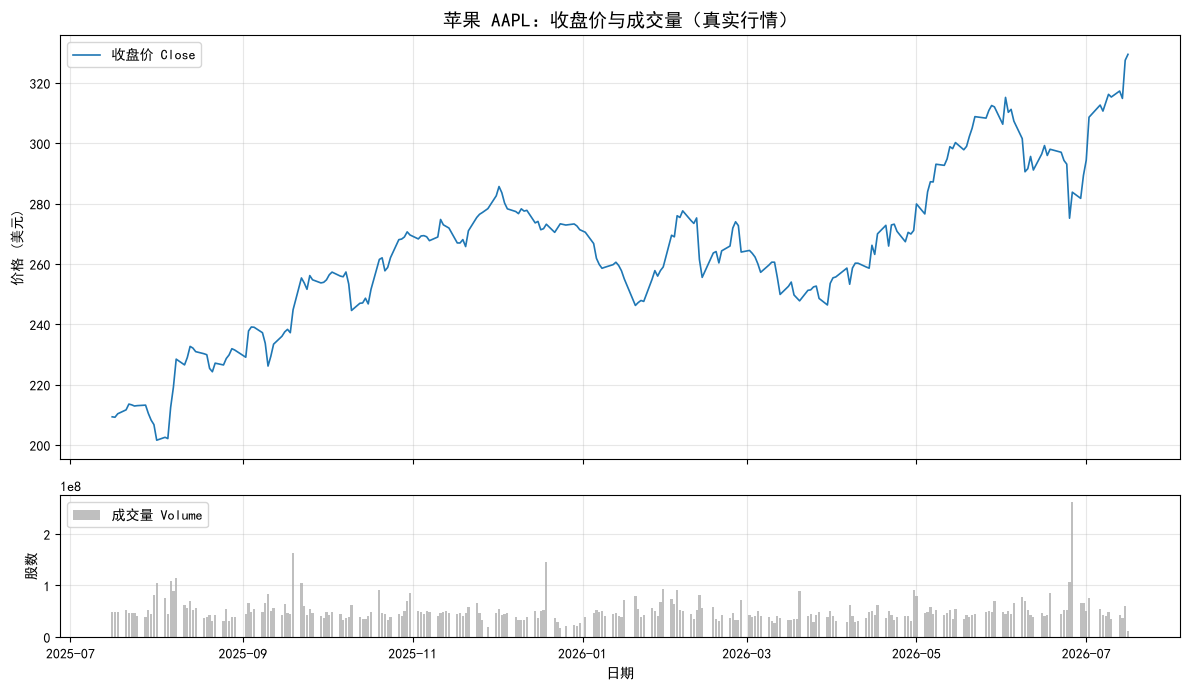

In [5]:
# ========== 配图1：收盘价折线 + 成交量柱状图 ==========
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True,  # 2行1列，共用日期横轴
                         gridspec_kw={'height_ratios': [3, 1]})  # 上图更高

axes[0].plot(aapl.index, aapl['Close'], color='tab:blue', linewidth=1.2, label='收盘价 Close')  # 上图：画折线
axes[0].set_ylabel('价格 (美元)')  # 设置上图纵轴
axes[0].set_title('苹果 AAPL：收盘价与成交量（真实行情）', fontsize=14)  # 设置上图标题
axes[0].legend(loc='upper left')  # 显示上图图例
axes[0].grid(True, alpha=0.3)  # 上图显示网格

axes[1].bar(aapl.index, aapl['Volume'], width=0.8, color='gray', alpha=0.5, label='成交量 Volume')  # 下图：画柱状图
axes[1].set_ylabel('股数')  # 设置下图纵轴
axes[1].legend(loc='upper left')  # 显示下图图例
axes[1].set_xlabel('日期')  # 设置下图横轴（日期）
axes[1].grid(True, alpha=0.3)  # 下图显示网格

plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切

plt.savefig('aapl_price_volume.png', dpi=150, bbox_inches='tight')
plt.show()                               # 在 Notebook 里显示图片


In [4]:
import pandas as pd
aapl = pd.read_csv(r'D:\NOTE\Quantforbeginner\quant_practice\aapl_1y.csv', index_col='Date', parse_dates=True)
aapl = aapl.dropna()
print(aapl.shape)
display(aapl.head())

(252, 5)


,Close,High,Low,Open,Volume
Date,,,,,
2025-07-16,209.329544,211.560683,207.815546,209.468990,47490500
2025-07-17,209.190109,210.963074,208.761800,209.737939,48068100
2025-07-18,210.345505,210.953095,208.871357,210.036732,48974600
2025-07-21,211.640366,214.927328,210.793734,211.261878,51377400
2025-07-22,213.552795,214.100625,211.391372,212.297780,46404100


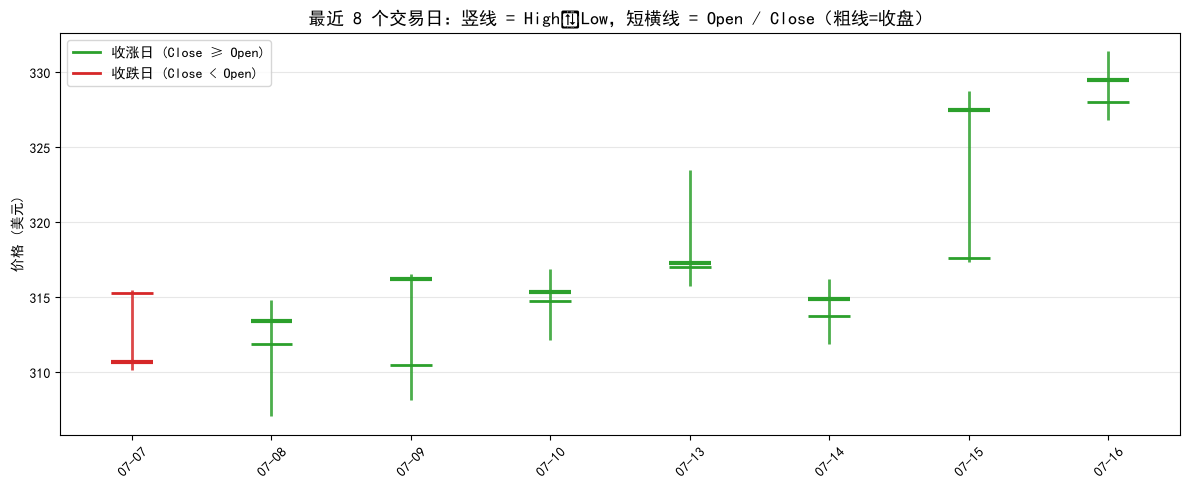

小贴士：一天之内，价格一定满足  Low ≤ Open, Close ≤ High


<Figure size 640x480 with 0 Axes>

In [6]:
# ========== 配图2：最近8天 OHLC 示意图 ==========
sample = aapl.tail(8).copy()   # 取最后 8 个交易日
dates = range(len(sample))     # 0,1,...,7 用作横轴位置

fig, ax = plt.subplots(figsize=(12, 5))  # 创建子图

for i, (idx, row) in enumerate(sample.iterrows()):  # 逐行遍历每一天
    o, h, l, c = row['Open'], row['High'], row['Low'], row['Close']  # 开高低收
    color = 'tab:red' if c < o else 'tab:green'   # 收跌红色、收涨绿色
    ax.vlines(i, l, h, color=color, linewidth=2, alpha=0.85)   # 竖线：最低到最高
    ax.hlines(o, i - 0.15, i + 0.15, color=color, linewidth=2)  # 开盘价短横线
    ax.hlines(c, i - 0.15, i + 0.15, color=color, linewidth=3)  # 收盘价粗横线

ax.set_xticks(dates)  # 设置横轴刻度位置
ax.set_xticklabels([d.strftime('%m-%d') for d in sample.index], rotation=45)  # 日期标签
ax.set_ylabel('价格 (美元)')  # 设置子图纵轴
ax.set_title('最近 8 个交易日：竖线 = High↔Low，短横线 = Open / Close（粗线=收盘）', fontsize=13)  # 设置子图标题
ax.grid(True, axis='y', alpha=0.3)  # 显示网格

from matplotlib.lines import Line2D  # 自定义图例用的小线段
legend_elements = [  # 自定义图例项
    Line2D([0], [0], color='tab:green', linewidth=2, label='收涨日 (Close ≥ Open)'),  # 线宽
    Line2D([0], [0], color='tab:red', linewidth=2, label='收跌日 (Close < Open)'),  # 线宽
]                                              # 数组拼接结束
ax.legend(handles=legend_elements, loc='upper left')  # 显示图例
plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切
plt.show()                               # 在 Notebook 里显示图片

plt.savefig('aapl_ohlc_8days.png', dpi=150, bbox_inches='tight')
print('小贴士：一天之内，价格一定满足  Low ≤ Open, Close ≤ High')  # 打印小贴士


In [7]:
# ========== 验证 100元→110元 的收益率例子 ==========
p_yesterday, p_today = 100, 110   # 昨天价、今天价
r = (p_today - p_yesterday) / p_yesterday  # 收益率公式
print(f'昨天: {p_yesterday} 元, 今天: {p_today} 元')  # 格式化打印
print(f'日收益率 r = {r:.2%}')  # :.2% 表示格式化为百分比，保留2位小数


昨天: 100 元, 今天: 110 元
日收益率 r = 10.00%


In [8]:
# ========== 用 pandas 计算整列日收益率 ==========
df = aapl[['Close']].copy()              # 只保留收盘价一列
df['日收益率'] = df['Close'].pct_change()  # 今天相对昨天的涨跌比例

print('最近 10 天的收盘价与日收益率：')  # 打印输出
display(df.tail(10))  # 在 Notebook 中美观显示表格

# 手算最后一天，和 pct_change 对照
row_today = df.iloc[-1]       # 最后一行（今天）
row_yesterday = df.iloc[-2]   # 倒数第二行（昨天）
manual_r = (row_today['Close'] - row_yesterday['Close']) / row_yesterday['Close']  # 手算收益率用于验证
print(f"\n验证最后一天：手算 {manual_r:.4%}，pct_change {row_today['日收益率']:.4%}")  # 对照手算与 pandas 结果
df.to_csv('aapl_daily_return.csv')

最近 10 天的收盘价与日收益率：


,Close,日收益率
Date,,
2026-07-02,308.630005,0.048407
2026-07-06,312.660004,0.013058
2026-07-07,310.660004,-0.006397
2026-07-08,313.390015,0.008788
2026-07-09,316.220001,0.009030
2026-07-10,315.320007,-0.002846
2026-07-13,317.309998,0.006311
2026-07-14,314.859985,-0.007721
2026-07-15,327.500000,0.040145



验证最后一天：手算 0.6015%，pct_change 0.6015%


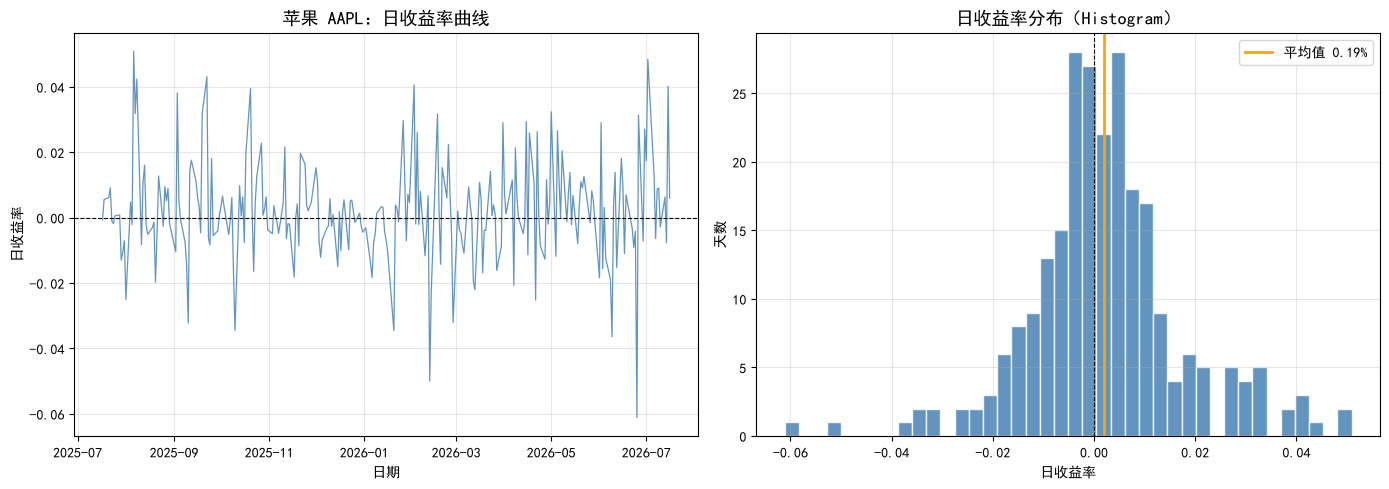

样本天数: 251
平均日收益率: 0.193%（正=整体偏多涨）
日收益率标准差: 1.536%（越大=波动越剧烈）


In [9]:
# ========== 日收益率曲线 + 直方图 ==========
rets = df['日收益率'].dropna()  # 去掉第一天的 NaN

fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 1行2列

axes[0].plot(rets.index, rets.values, color='steelblue', linewidth=0.9, alpha=0.85)  # 上图：画折线
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')  # 零轴参考线
axes[0].set_title('苹果 AAPL：日收益率曲线', fontsize=13)  # 设置上图标题
axes[0].set_xlabel('日期')  # 执行本行代码
axes[0].set_ylabel('日收益率')  # 设置上图纵轴
axes[0].grid(True, alpha=0.3)  # 上图显示网格

axes[1].hist(rets.values, bins=40, color='steelblue', edgecolor='white', alpha=0.85)  # 画直方图
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')  # 中图画垂直参考线
axes[1].axvline(rets.mean(), color='orange', linewidth=2, label=f'平均值 {rets.mean():.2%}')  # 求平均值
axes[1].set_title('日收益率分布（Histogram）', fontsize=13)  # 设置下图标题
axes[1].set_xlabel('日收益率')  # 设置下图横轴（日期）
axes[1].set_ylabel('天数')  # 设置下图纵轴
axes[1].legend()                                    # 显示下图图例
axes[1].grid(True, alpha=0.3)  # 下图显示网格

plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切
plt.savefig('aapl_return_distribution.png', dpi=150, bbox_inches='tight')
plt.show()                               # 在 Notebook 里显示图片

print(f'样本天数: {len(rets)}')  # 打印统计结果
print(f'平均日收益率: {rets.mean():.3%}（正=整体偏多涨）')  # 格式化打印
print(f'日收益率标准差: {rets.std():.3%}（越大=波动越剧烈）')  # 格式化打印


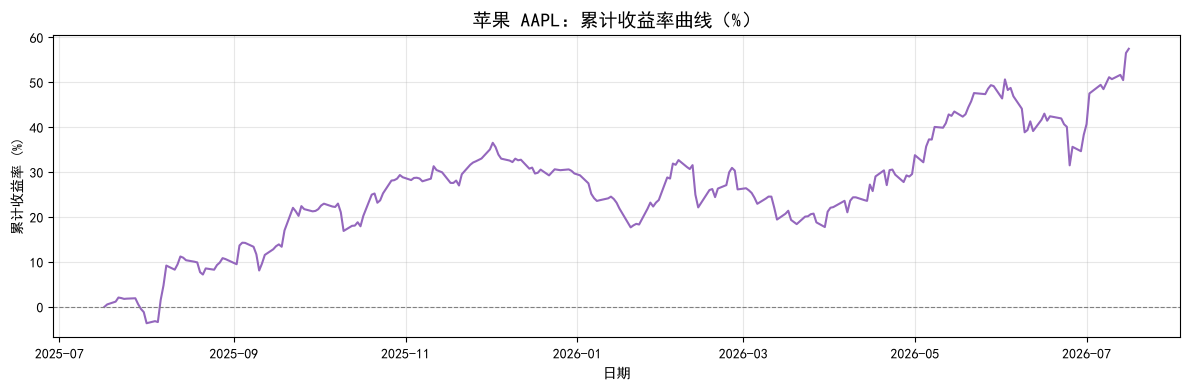

这段区间累计涨跌: 57.39%


In [10]:
# ========== 累计收益率曲线 ==========
cum_return = (1 + rets).cumprod() - 1  # 每天 (1+r) 连乘，再减1得到累计涨跌

plt.figure(figsize=(12, 4))  # 创建画布
plt.plot(cum_return.index, cum_return.values * 100, color='tab:purple', linewidth=1.5)  # 画折线图
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)  # 画水平参考线
plt.title('苹果 AAPL：累计收益率曲线（%）', fontsize=14)  # 设置图标题
plt.xlabel('日期')  # 设置横轴标签
plt.ylabel('累计收益率 (%)')  # 设置纵轴标签
plt.grid(True, alpha=0.3)  # 显示网格线
plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切
plt.savefig('aapl_cumulative_return.png', dpi=150, bbox_inches='tight')
plt.show()                               # 在 Notebook 里显示图片

print(f'这段区间累计涨跌: {cum_return.iloc[-1]:.2%}')  # 打印价格统计


In [11]:
# ========== 小实验：下载三只股票并算波动 ==========
tickers = {  # 要对比的股票列表
    'AAPL': '苹果',  # 字典字段
    'TSLA': '特斯拉',  # 字典字段
    'NVDA': '英伟达',  # 字典字段
}  # 执行本行代码

period = '1y'   # 时间长度，可改成 '6mo'、'2y'
all_rets = {}   # 用字典存每只股票的中文名 → 日收益率序列

for symbol, name in tickers.items():  # 逐只股票下载
    data = yf.download(symbol, period=period, progress=False, multi_level_index=False).dropna()  # 下载股票日线行情
    all_rets[name] = data['Close'].pct_change().dropna()  # 只关心收盘价涨跌
    print(f'{name} ({symbol}): {len(all_rets[name])} 个交易日')  # 打印统计结果

vol = pd.Series({name: s.std() for name, s in all_rets.items()}).sort_values(ascending=False)  # 求标准差（波动大小）
print('\n=== 日收益率波动（标准差，越大越猛）===')  # 打印分隔线或结论
for name, v in vol.items():  # 代码块开始
    print(f'  {name}: {v:.3%}')  # 格式化打印

# ========== 保存数据 ==========
returns_df = pd.DataFrame(all_rets)          # 把三只股票的日收益率合并成一张表（按日期对齐）
returns_df.to_csv('three_stocks_daily_returns.csv')  # 保存每日收益率明细
vol.to_csv('three_stocks_volatility.csv', header=['日收益率标准差'])  # 保存波动率对比结果
print('\n已保存：three_stocks_daily_returns.csv、three_stocks_volatility.csv')


1 Failed download:
['AAPL']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


苹果 (AAPL): 0 个交易日



1 Failed download:
['TSLA']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


特斯拉 (TSLA): 0 个交易日



1 Failed download:
['NVDA']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


英伟达 (NVDA): 0 个交易日

=== 日收益率波动（标准差，越大越猛）===
  苹果: nan%
  特斯拉: nan%
  英伟达: nan%

已保存：three_stocks_daily_returns.csv、three_stocks_volatility.csv


In [13]:
import pandas as pd

returns_df = pd.read_csv('three_stocks_daily_returns.csv', index_col=0, parse_dates=True)
vol = pd.read_csv('three_stocks_volatility.csv', index_col=0)['日收益率标准差']

all_rets = {col: returns_df[col].dropna() for col in returns_df.columns} 
period = '1y' 

print('=== 日收益率波动（标准差，越大越猛）===')
for name, v in vol.items():
    print(f'  {name}: {v:.3%}')

=== 日收益率波动（标准差，越大越猛）===
  特斯拉: 2.812%
  英伟达: 2.259%
  苹果: 1.536%


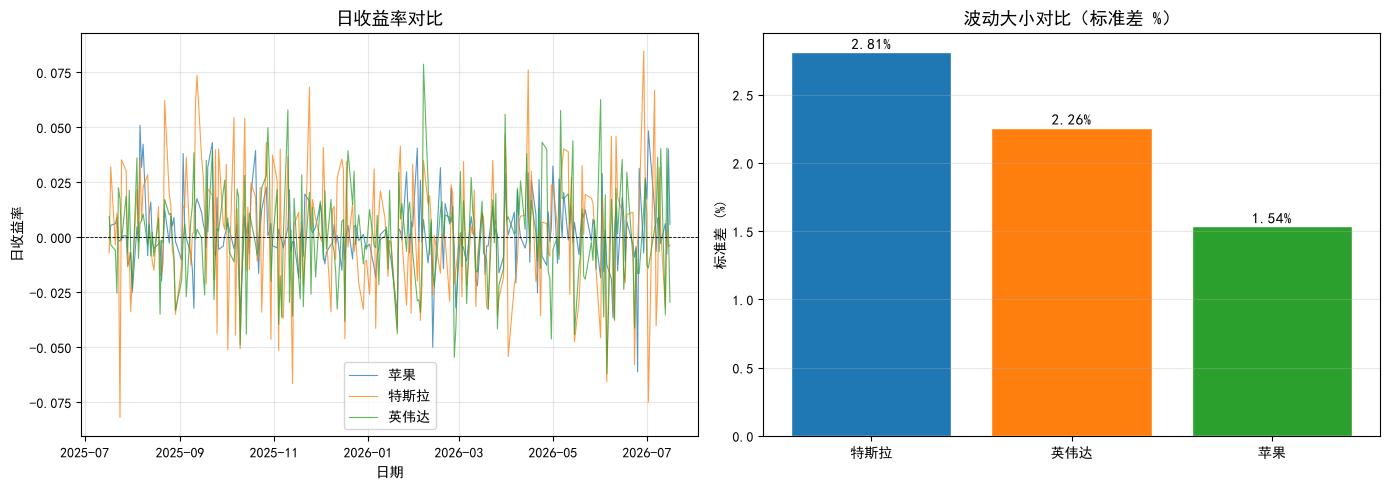


在本实验设定下（1y 日线），波动最大的是：特斯拉


In [14]:
# ========== 三只股票收益率对比图 ==========
fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 创建子图
colors = ['tab:blue', 'tab:orange', 'tab:green']  # 各曲线颜色

for (name, series), c in zip(all_rets.items(), colors):  # 逐只股票画曲线
    axes[0].plot(series.index, series.values, label=name, alpha=0.75, linewidth=0.8)  # 上图：画折线
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.6)  # 上图画参考线
axes[0].set_title('日收益率对比', fontsize=13)  # 设置上图标题
axes[0].set_xlabel('日期')  # 执行本行代码
axes[0].set_ylabel('日收益率')  # 设置上图纵轴
axes[0].legend()  # 显示上图图例
axes[0].grid(True, alpha=0.3)  # 上图显示网格

axes[1].bar(vol.index, vol.values * 100, color=colors[: len(vol)], edgecolor='white')  # 下图：画柱状图
axes[1].set_title('波动大小对比（标准差 %）', fontsize=13)  # 设置下图标题
axes[1].set_ylabel('标准差 (%)')  # 设置下图纵轴
axes[1].grid(True, axis='y', alpha=0.3)  # 下图显示网格
for i, v in enumerate(vol.values):  # 在柱顶标注数值
    axes[1].text(i, v * 100 + 0.02, f'{v:.2%}', ha='center', fontsize=11)  # 字号

plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切
plt.savefig('three_stocks_comparison.png', dpi=150, bbox_inches='tight')  # 保存图片到当前文件夹
plt.show()                               # 在 Notebook 里显示图片

winner = vol.index[0]  # 波动最大的股票
print(f'\n在本实验设定下（{period} 日线），波动最大的是：{winner}')  # 格式化打印

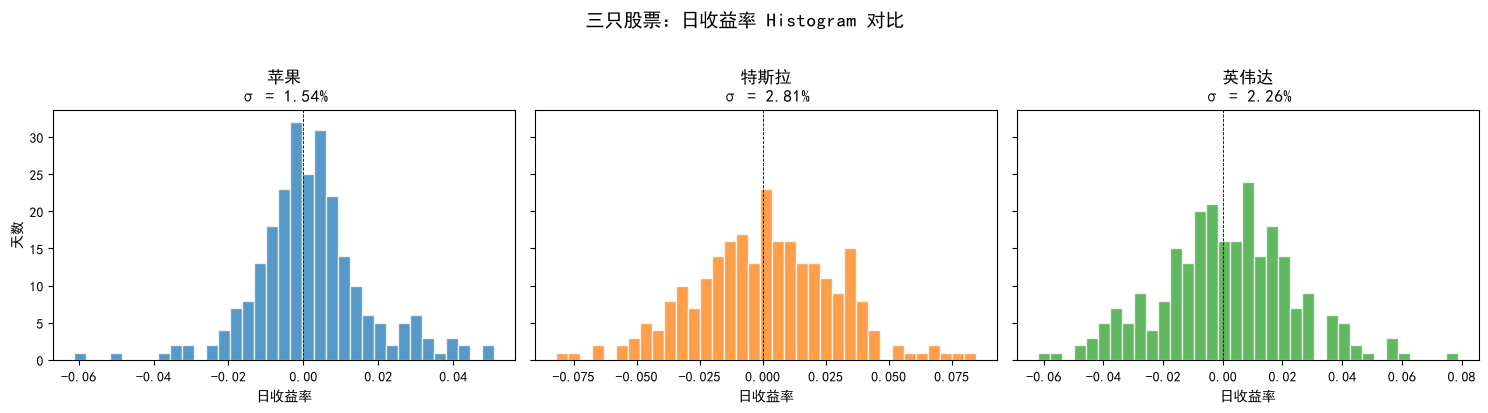

In [16]:
# ========== 三只股票 Histogram 并排对比 ==========
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)  # 创建子图

for ax, (name, series), c in zip(axes, all_rets.items(), colors):  # 逐只股票画直方图
    ax.hist(series.values, bins=35, color=c, alpha=0.75, edgecolor='white')  # 透明度
    ax.axvline(0, color='black', linestyle='--', linewidth=0.6)  # 画垂直参考线
    ax.set_title(f'{name}\nσ = {series.std():.2%}')  # 求标准差（波动大小）
    ax.set_xlabel('日收益率')  # 设置子图横轴

axes[0].set_ylabel('天数')  # 设置上图纵轴
fig.suptitle('三只股票：日收益率 Histogram 对比', fontsize=14, y=1.02)  # 整张图的总标题
plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切
plt.savefig('three_stocks_histogram.png', dpi=150, bbox_inches='tight')
plt.show()                               # 在 Notebook 里显示图片


In [17]:
# ========== 挑战任务1：换成自己喜欢的公司，重做波动对比实验 ==========
tickers = {  # 要对比的股票列表
    'MSFT': '微软',  # 字典字段
    'GOOGL': '谷歌',  # 字典字段
    'AMD': 'AMD',  # 字典字段
}  # 执行本行代码

period = '1y'   # 时间长度，可改成 '6mo'、'2y'
all_rets = {}   # 用字典存每只股票的中文名 → 日收益率序列

for symbol, name in tickers.items():  # 逐只股票下载
    data = yf.download(symbol, period=period, progress=False, multi_level_index=False).dropna()  # 下载股票日线行情
    all_rets[name] = data['Close'].pct_change().dropna()  # 只关心收盘价涨跌
    print(f'{name} ({symbol}): {len(all_rets[name])} 个交易日')  # 打印统计结果

vol = pd.Series({name: s.std() for name, s in all_rets.items()}).sort_values(ascending=False)  # 求标准差（波动大小）
print('\n=== 日收益率波动（标准差，越大越猛）===')  # 打印分隔线或结论
for name, v in vol.items():  # 代码块开始
    print(f'  {name}: {v:.3%}')  # 格式化打印

# ========== 保存数据 ==========
returns_df = pd.DataFrame(all_rets)          # 把三只股票的日收益率合并成一张表（按日期对齐）
returns_df.to_csv('challenge_daily_returns.csv')  # 保存每日收益率明细
vol.to_csv('challenge_volatility.csv', header=['日收益率标准差'])  # 保存波动率对比结果
print('\n已保存：challenge_daily_returns.csv、challenge_volatility.csv')



1 Failed download:
['MSFT']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


微软 (MSFT): 0 个交易日



1 Failed download:
['GOOGL']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


谷歌 (GOOGL): 0 个交易日



1 Failed download:
['AMD']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


AMD (AMD): 0 个交易日

=== 日收益率波动（标准差，越大越猛）===
  微软: nan%
  谷歌: nan%
  AMD: nan%

已保存：challenge_daily_returns.csv、challenge_volatility.csv


In [18]:

import pandas as pd

returns_df = pd.read_csv('challenge_daily_returns.csv', index_col=0, parse_dates=True)
vol = pd.read_csv('challenge_volatility.csv', index_col=0)['日收益率标准差']

all_rets = {col: returns_df[col].dropna() for col in returns_df.columns} 
period = '1y'  # 对应下载时用的时间范围

print('=== 日收益率波动（标准差，越大越猛）===')
for name, v in vol.items():
    print(f'  {name}: {v:.3%}')

=== 日收益率波动（标准差，越大越猛）===
  AMD: 4.339%
  谷歌: 1.894%
  微软: 1.725%


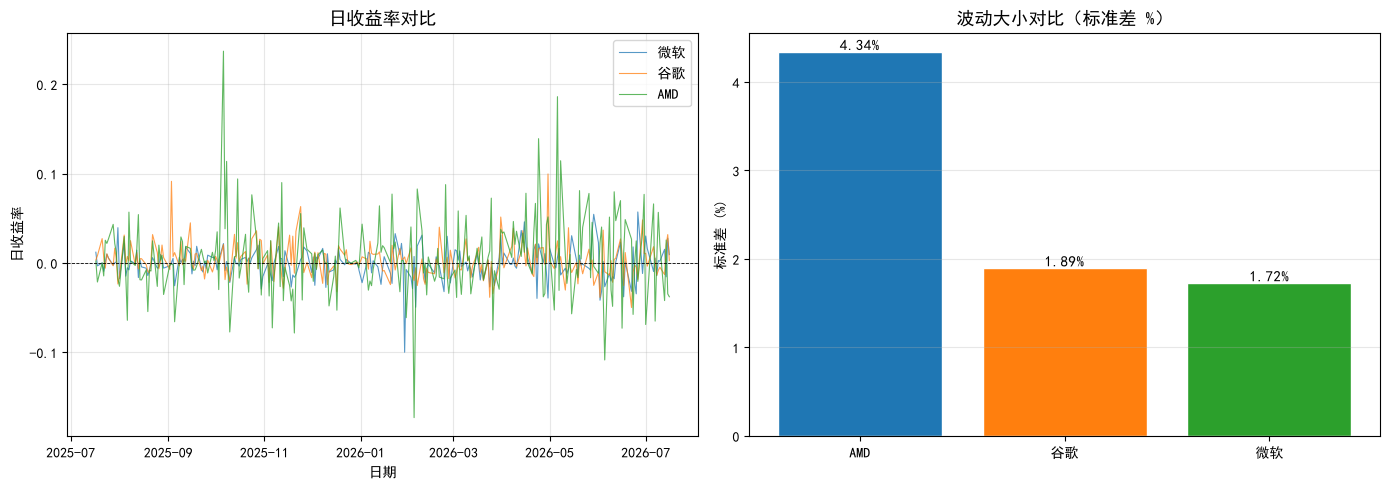


在本实验设定下（1y 日线），波动最大的是：AMD


In [19]:
# ========== 三只股票收益率对比图 ==========
fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 创建子图
colors = ['tab:blue', 'tab:orange', 'tab:green']  # 各曲线颜色

for (name, series), c in zip(all_rets.items(), colors):  # 逐只股票画曲线
    axes[0].plot(series.index, series.values, label=name, alpha=0.75, linewidth=0.8)  # 上图：画折线
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.6)  # 上图画参考线
axes[0].set_title('日收益率对比', fontsize=13)  # 设置上图标题
axes[0].set_xlabel('日期')  # 执行本行代码
axes[0].set_ylabel('日收益率')  # 设置上图纵轴
axes[0].legend()  # 显示上图图例
axes[0].grid(True, alpha=0.3)  # 上图显示网格

axes[1].bar(vol.index, vol.values * 100, color=colors[: len(vol)], edgecolor='white')  # 下图：画柱状图
axes[1].set_title('波动大小对比（标准差 %）', fontsize=13)  # 设置下图标题
axes[1].set_ylabel('标准差 (%)')  # 设置下图纵轴
axes[1].grid(True, axis='y', alpha=0.3)  # 下图显示网格
for i, v in enumerate(vol.values):  # 在柱顶标注数值
    axes[1].text(i, v * 100 + 0.02, f'{v:.2%}', ha='center', fontsize=11)  # 字号

plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切
plt.savefig('challenge_comparison.png', dpi=150, bbox_inches='tight')  # 保存图片到当前文件夹
plt.show()                               # 在 Notebook 里显示图片

winner = vol.index[0]  # 波动最大的股票
print(f'\n在本实验设定下（{period} 日线），波动最大的是：{winner}')  # 格式化打印

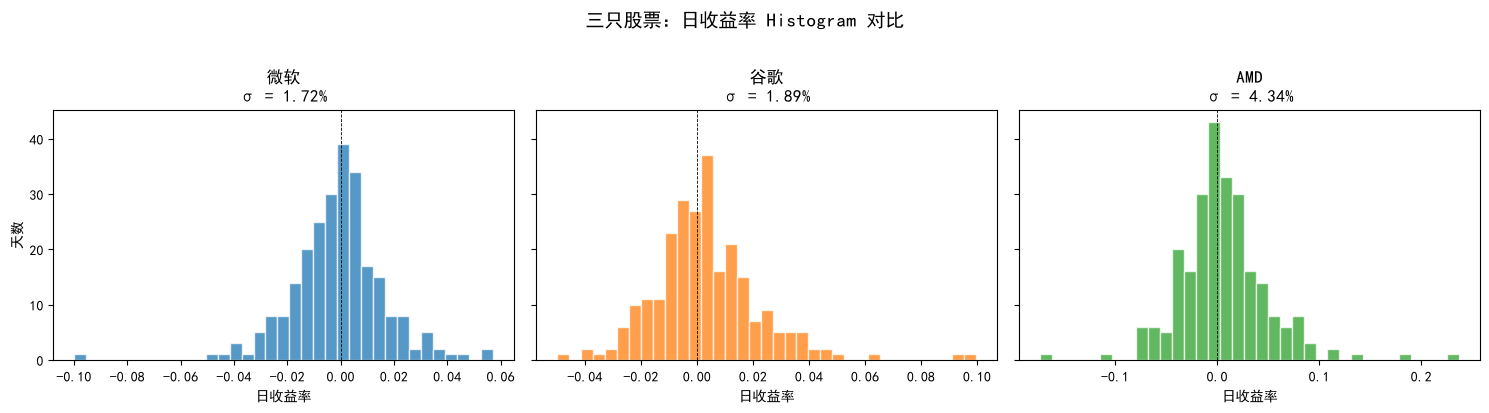

In [21]:
# 第三步：Histogram 对比图
# ========== 三只股票 Histogram 并排对比 ==========
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)  # 创建子图

for ax, (name, series), c in zip(axes, all_rets.items(), colors):  # 逐只股票画直方图
    ax.hist(series.values, bins=35, color=c, alpha=0.75, edgecolor='white')  # 透明度
    ax.axvline(0, color='black', linestyle='--', linewidth=0.6)  # 画垂直参考线
    ax.set_title(f'{name}\nσ = {series.std():.2%}')  # 求标准差（波动大小）
    ax.set_xlabel('日收益率')  # 设置子图横轴

axes[0].set_ylabel('天数')  # 设置上图纵轴
fig.suptitle('三只股票：日收益率 Histogram 对比', fontsize=14, y=1.02)  # 整张图的总标题
plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切
plt.savefig('challenge_histogram.png', dpi=150, bbox_inches='tight')  # 保存图片到当前文件夹
plt.show()                               # 在 Notebook 里显示图片
